# Módulo 3 — Informe de sesgos

**Proyecto:** TinderJob 
Este módulo documenta los sesgos detectados en los datasets: su origen, cómo los identifiqué y qué impacto tendrían en decisiones de negocio o en un modelo predictivo.

> **Clave del proyecto:** no basta con detectar sesgos. Hay que reflexionar sobre qué decisiones se tomarían erróneamente si no se tienen en cuenta.

---

In [1]:
# Importo librerías y cargo los datos
# I import libraries and load the data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14

# Dataset limpio de Tecnoempleo (mercado español)
# Clean Tecnoempleo dataset (Spanish market)
df = pd.read_csv('../data/processed/clean_tecnoempleo_jobs.csv')

# DS Salaries para análisis de sesgos globales
# DS Salaries for global bias analysis
df_sal = pd.read_csv('../data/ds_salaries.csv')
df_sal['salary_in_eur'] = df_sal['salary_in_usd'] * 0.92

print(f"Tecnoempleo: {df.shape[0]} ofertas")
print(f"DS Salaries: {df_sal.shape[0]} registros")

Tecnoempleo: 1148 ofertas
DS Salaries: 607 registros


---
## Sesgo 1 — Ausencia de salarios en Tecnoempleo (MNAR)

### ¿Qué es MNAR?
**MNAR** (Missing Not At Random) significa que los valores ausentes no son aleatorios: su ausencia está relacionada con el propio valor que falta.

En Tecnoempleo: las empresas que **no publican el salario** no lo hacen al azar. Tienden a omitirlo cuando el salario es bajo (para no desincentivar candidatos) o cuando es muy alto (estrategia de negociación). Esto no es aleatoriedad — es una decisión deliberada.

In [3]:
# Cuantifico los valores nulos en salario y analizo si hay patrón
# I quantify null values in salary and analyze if there is a pattern
total = len(df)
nulos_salario = df['salario'].isnull().sum()
pct = nulos_salario / total * 100

print("=" * 55)
print("ANÁLISIS MNAR — SALARIO (Tecnoempleo)")
print("=" * 55)
print(f"  Total ofertas              : {total}")
print(f"  Sin dato de salario (NaN)  : {nulos_salario} ({pct:.1f}%)")
print(f"  Con dato de salario        : {total - nulos_salario} ({100-pct:.1f}%)")

# Comparo si las ofertas con/sin salario tienen distinto perfil de búsqueda
# I compare if offers with/without salary have different search profiles
df['tiene_salario'] = df['salario'].notna()
comparacion = (
    df.groupby('tiene_salario')['busqueda']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .T
)
comparacion.columns = ['Sin salario', 'Con salario']
print("\n¿Las ofertas con salario se concentran en ciertos perfiles?")
print(comparacion.sort_values('Con salario', ascending=False).head(10).round(3).to_string())

ANÁLISIS MNAR — SALARIO (Tecnoempleo)
  Total ofertas              : 1148
  Sin dato de salario (NaN)  : 927 (80.7%)
  Con dato de salario        : 221 (19.3%)

¿Las ofertas con salario se concentran en ciertos perfiles?
                        Sin salario  Con salario
busqueda                                        
soporte-tecnico               0.055        0.113
desarrollador-web             0.043        0.100
programador                   0.058        0.100
analista-programador          0.037        0.095
data-engineer                 0.054        0.072
devops                        0.057        0.063
business-intelligence         0.050        0.045
arquitecto-tic                0.067        0.045
junior                        0.047        0.045
administrador-sistemas        0.026        0.041


**📋 Análisis del Sesgo 1 — MNAR en Tecnoempleo:**

| Aspecto | Detalle |
|---|---|
| **Tipo** | MNAR (Missing Not At Random) |
| **Variable afectada** | `salario` — 80.7% de valores nulos (927 de 1.148 ofertas) |
| **Origen** | Las empresas omiten el salario de forma deliberada: estrategia de negociación, evitar comparaciones o atraer candidatos sin anclar expectativas |
| **Cómo lo detecté** | El patrón no es aleatorio: soporte-técnico (11.3%), desarrollador-web (10%) y programador (10%) publican salario con el doble de frecuencia que arquitecto-tic (4.5%) o junior (4.5%). Los perfiles más "commoditizados" publican más, los más especializados menos |
| **Impacto en modelo predictivo** | Un modelo entrenado con estos datos aprendería solo de los casos donde la empresa decidió publicar el salario — muestra sesgada hacia perfiles concretos y rangos medios, invisibilizando los extremos |
| **Impacto para DataTalent** | No se puede usar Tecnoempleo como fuente salarial del mercado español. Para análisis salariales, DS Salaries (con sus limitaciones geográficas) o fuentes como InfoJobs son más fiables |

---
## Sesgo 2 — Sesgo de búsqueda en Tecnoempleo

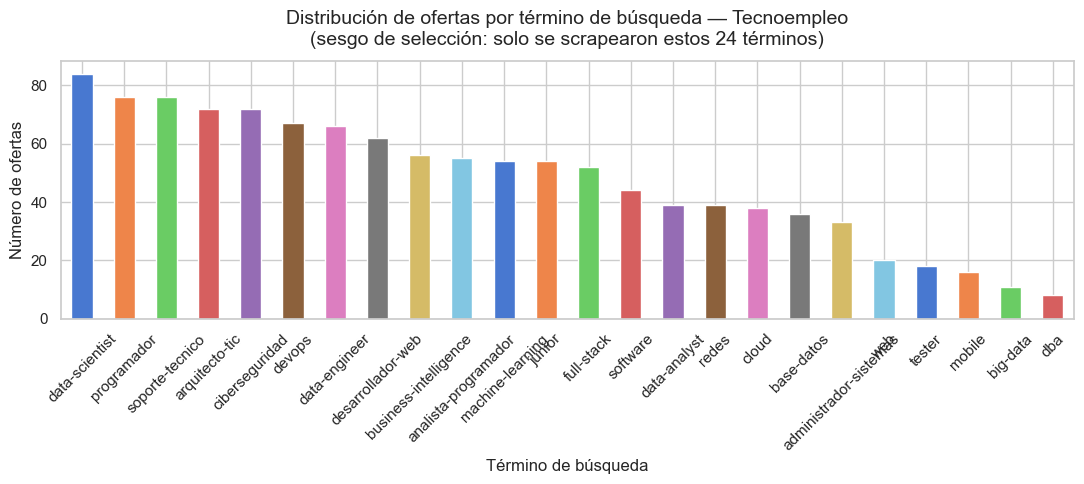

busqueda
data-scientist            84
programador               76
soporte-tecnico           76
arquitecto-tic            72
ciberseguridad            72
devops                    67
data-engineer             66
desarrollador-web         62
business-intelligence     56
analista-programador      55
machine-learning          54
junior                    54
full-stack                52
software                  44
data-analyst              39
redes                     39
cloud                     38
base-datos                36
administrador-sistemas    33
web                       20
tester                    18
mobile                    16
big-data                  11
dba                        8


In [4]:
# Analizo la distribución de ofertas por término de búsqueda
# I analyze the distribution of offers by search term
# El dataset se construyó buscando términos predefinidos — esto introduce sesgo
# The dataset was built by searching predefined terms — this introduces bias
busqueda_counts = df['busqueda'].value_counts()

fig, ax = plt.subplots(figsize=(11, 5))
busqueda_counts.plot(kind='bar', ax=ax,
    color=sns.color_palette('muted', len(busqueda_counts)), edgecolor='white')
ax.set_title('Distribución de ofertas por término de búsqueda — Tecnoempleo\n(sesgo de selección: solo se scrapearon estos 24 términos)', pad=12)
ax.set_xlabel('Término de búsqueda')
ax.set_ylabel('Número de ofertas')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('../data/processed/sesgo_busqueda.png', dpi=150, bbox_inches='tight')
plt.show()
print(busqueda_counts.to_string())

**📋 Análisis del Sesgo 2 — Sesgo de búsqueda:**

| Aspecto | Detalle |
|---|---|
| **Tipo** | Sesgo de selección / Recolección |
| **Origen** | El scraper solo buscó 24 términos predefinidos. Ofertas con otros títulos (ej: 'Analista de datos', 'Técnico BI') no están en el dataset |
| **Cómo lo detecté** | La columna `busqueda` solo contiene los 24 términos del script — no existe variedad real |
| **Impacto en modelo** | Un modelo entrenado con estos datos aprendería que el mercado está dominado por estos 24 perfiles exactos, cuando en realidad hay más diversidad de títulos |
| **Impacto para DataTalent** | Las recomendaciones de reskilling basadas en este dataset pueden excluir perfiles relevantes que simplemente no se buscaron |

---
## Sesgo 3 — Subrepresentación geográfica en DS Salaries

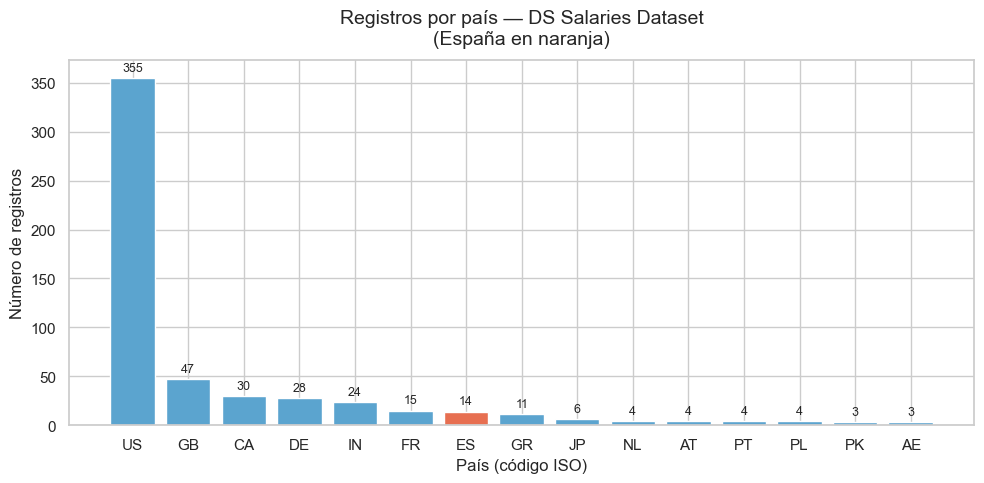


España: 14 registros de 607 totales (2.3%)
⚠️  Con solo 14 registros, los estadísticos de España NO son fiables.


In [6]:
# Comparo el peso de España frente a otros países en DS Salaries
# I compare Spain's weight against other countries in DS Salaries
paises_top = df_sal['company_location'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
# Marco España en naranja para destacarla visualmente
# I mark Spain in orange to highlight it visually
colors = ['#e76f51' if c == 'ES' else '#5ba4cf' for c in paises_top.index]
bars = ax.bar(paises_top.index, paises_top.values, color=colors, edgecolor='white')
ax.set_title('Registros por país — DS Salaries Dataset\n(España en naranja)', pad=12)
ax.set_xlabel('País (código ISO)')
ax.set_ylabel('Número de registros')
ax.bar_label(bars, padding=3, fontsize=9)
plt.tight_layout()
plt.savefig('../data/processed/sesgo_geografico.png', dpi=150, bbox_inches='tight')
plt.show()

n_spain = df_sal[df_sal['company_location'] == 'ES'].shape[0]
pct_spain = n_spain / df_sal.shape[0] * 100
print(f"\nEspaña: {n_spain} registros de {df_sal.shape[0]} totales ({pct_spain:.1f}%)")
print("⚠️  Con solo 14 registros, los estadísticos de España NO son fiables.")

**📋 Análisis del Sesgo 3 — Subrepresentación geográfica:**

| Aspecto | Detalle |
|---|---|
| **Tipo** | Sesgo geográfico / Muestra insuficiente |
| **Origen** | El dataset DS Salaries está dominado por EEUU (355 registros, 58.5% del total). España tiene solo 14 registros sobre 607 totales (2.3%) |
| **Cómo lo detecté** | Filtrando `company_location == 'ES'` — el resultado es 14 filas, menos que países como Grecia (11) o India (24) |
| **Impacto en modelo** | Con 14 registros, un único outlier puede distorsionar completamente la media española. El margen de error estadístico es inaceptable para tomar decisiones |
| **Impacto para DataTalent** | Cualquier estadístico calculado sobre España en DS Salaries es anecdótico, no representativo. Para el mercado español, Tecnoempleo (cuando publique salarios) o InfoJobs son las fuentes adecuadas |

---
## Resumen ejecutivo — Tabla de sesgos

| # | Sesgo | Dataset | Tipo | Cómo lo detecté | Impacto en modelo | Impacto en negocio |
|---|---|---|---|---|---|---|
| 1 | Ausencia de salarios | Tecnoempleo | **MNAR** | 80.7% NaN; patrón no aleatorio por perfil | Muestra sesgada hacia rangos medios | No permite análisis salarial del mercado español |
| 2 | Sesgo de búsqueda | Tecnoempleo | **Selección** | Solo 24 términos predefinidos en `busqueda` | Mercado aparentemente más homogéneo de lo real | Excluye perfiles relevantes no contemplados en el scraping |
| 3 | Subrepresentación España | DS Salaries | **Geográfico** | Solo 14 registros ES sobre 607 totales (2.3%) | Alta varianza, conclusiones no generalizables | No usar como referencia del mercado español |

---
## Recomendaciones para DataTalent Solutions S.L.

1. **Comunicar siempre la mediana** salarial, nunca la media — la distribución es asimétrica.
2. **No usar Tecnoempleo como fuente salarial** — el 80.7% de nulos hace inviable cualquier análisis salarial.
3. **Ampliar los términos de búsqueda** del scraper en futuras iteraciones para reducir el sesgo de selección.
4. **Complementar con fuentes españolas** (InfoJobs, LinkedIn España) para análisis salariales fiables.
5. **No entrenar modelos de selección** con estos datasets sin aplicar técnicas de debiasing previas.
6. **Comunicar la incertidumbre** al equipo directivo: las cifras son orientativas, no exactas.

---
